In [1]:
import paddle
print(paddle.utils.run_check())

/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Running verify PaddlePaddle program ... 


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/pir/math_op_patch.py:241: UserWarning: Tensor do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(
I0316 02:35:46.326020 1807799 pir_interpreter.cc:1529] New Executor is Running ...
I0316 02:35:46.326313 1807799 pir_interpreter.cc:1552] pir interpreter is running by multi-thread mode ...


PaddlePaddle works well on 1 CPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
None


In [ ]:
from pathlib import Path
import subprocess
import sys

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
SCRIPT_PATH = BASE_DIR / "ppstructurev3_to_md.py"
OUT_DIR = BASE_DIR / "outputs_ppstructurev3_md"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay script: {SCRIPT_PATH}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc data: {DATA_DIR}")

pdf_files = sorted(DATA_DIR.rglob("*.pdf"))
print(f"Tim thay {len(pdf_files)} file PDF trong {DATA_DIR}")

for i, pdf_path in enumerate(pdf_files, 1):
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--input", str(pdf_path),
        "--output_dir", str(OUT_DIR),
        "--lang", "vi",
        "--device", "cpu",
        "--disable_mkldnn",
        "--page_header",
    ]

    print(f"[{i}/{len(pdf_files)}] Dang xu ly: {pdf_path.name}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("  OK")
    else:
        print("  FAIL")
        print(result.stderr[-1200:])

print(f"\nXong. File markdown o: {OUT_DIR}")

Tim thay 11 file PDF
[1/11] Dang xu ly: Public001.pdf
  OK  -> Public001_paddle_det_vietocr.txt
[2/11] Dang xu ly: Public002.pdf
  OK  -> Public002_paddle_det_vietocr.txt
[3/11] Dang xu ly: Public003.pdf
  OK  -> Public003_paddle_det_vietocr.txt
[4/11] Dang xu ly: Public004.pdf
  OK  -> Public004_paddle_det_vietocr.txt
[5/11] Dang xu ly: Public005.pdf
  OK  -> Public005_paddle_det_vietocr.txt
[6/11] Dang xu ly: Public253.pdf
  OK  -> Public253_paddle_det_vietocr.txt
[7/11] Dang xu ly: Public257.pdf


In [ ]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

import pypdfium2 as pdfium

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data_3" / "06_ Quy định ngoại ngữ từ K70_chính quy_final.pdf"
SCRIPT_PATH = BASE_DIR / "ppstructurev3_to_md.py"
PAGE_IMG_DIR = BASE_DIR / "debug"
PAGE_OUT_DIR = BASE_DIR / "outputs_ppstructurev3_md" / "Test_pages"

PAGE_NUMBERS = None
SCALE = 2.0

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file PDF: {PDF_PATH}")
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay script: {SCRIPT_PATH}")

if PAGE_IMG_DIR.exists():
    shutil.rmtree(PAGE_IMG_DIR)
PAGE_IMG_DIR.mkdir(parents=True, exist_ok=True)
PAGE_OUT_DIR.mkdir(parents=True, exist_ok=True)

pdf = pdfium.PdfDocument(str(PDF_PATH))
total_pages = len(pdf)
selected_pages = PAGE_NUMBERS or list(range(1, total_pages + 1))

print(f"Tong so trang: {total_pages}")
print(f"Se chay cac trang: {selected_pages}")

page_timings = []
failed_pages = []

for page_number in selected_pages:
    page_index = page_number - 1
    page = pdf[page_index]
    bitmap = page.render(scale=SCALE)
    pil_image = bitmap.to_pil()

    page_img_path = PAGE_IMG_DIR / f"Test_page_{page_number:03d}.png"
    pil_image.save(page_img_path)

    start_time = time.time()
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--input", str(page_img_path),
        "--output_dir", str(PAGE_OUT_DIR),
        "--lang", "vi",
        "--device", "cpu",
        "--vietocr_device", "cpu",
        "--disable_mkldnn",
        "--page_header",
    ]

    print(f"\nDang xu ly trang {page_number}: {page_img_path.name}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - start_time

    if result.returncode == 0:
        print(f"  OK - {elapsed:.1f}s")
        page_timings.append((page_number, elapsed))
    else:
        print(f"  FAIL - {elapsed:.1f}s")
        failed_pages.append(page_number)
        if result.stderr:
            print(result.stderr[-1500:])
        elif result.stdout:
            print(result.stdout[-1500:])

print("\nTong ket theo trang")
for page_number, elapsed in page_timings:
    print(f"- Trang {page_number}: {elapsed:.1f}s")

if failed_pages:
    print("\nTrang loi:")
    for page_number in failed_pages:
        print(f"- Trang {page_number}")

print(f"\nAnh tung trang nam o: {PAGE_IMG_DIR}")
print(f"Markdown tung trang nam o: {PAGE_OUT_DIR}")

In [ ]:
from pathlib import Path
import subprocess
import sys
import time

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "input"
MARKER_OUT_ROOT = BASE_DIR / "outputs"
MARKER_OUT_ROOT.mkdir(parents=True, exist_ok=True)

PAGE_RANGE = None
TIMEOUT_SECONDS = 1800 
MAX_FILES = None 

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc: {DATA_DIR}")

pdf_files = sorted(DATA_DIR.rglob("*.pdf"))
if MAX_FILES is not None:
    pdf_files = pdf_files[:MAX_FILES]

if not pdf_files:
    raise FileNotFoundError(f"Khong tim thay file PDF trong: {DATA_DIR}")

marker_single = Path(sys.executable).parent / "marker_single"
if not marker_single.exists():
    print("Khong tim thay marker_single, dang cai marker-pdf...")
    install_cmd = [sys.executable, "-m", "pip", "install", "marker-pdf"]
    install_result = subprocess.run(install_cmd, capture_output=True, text=True)
    if install_result.returncode != 0:
        print(install_result.stdout[-2000:])
        print(install_result.stderr[-2000:])
        raise RuntimeError("Cai marker-pdf that bai")
    marker_single = Path(sys.executable).parent / "marker_single"
    if not marker_single.exists():
        raise FileNotFoundError(f"Da cai marker-pdf nhung van khong tim thay marker_single: {marker_single}")

print(f"Tim thay {len(pdf_files)} file PDF trong {DATA_DIR}")

success_files = []
failed_files = []

for i, pdf_path in enumerate(pdf_files, 1):
    cmd = [
        str(marker_single),
        str(pdf_path),
        "--output_dir", str(MARKER_OUT_ROOT),
        "--output_format", "markdown",
        "--disable_multiprocessing",
    ]
    if PAGE_RANGE:
        cmd.extend(["--page_range", PAGE_RANGE])

    print(f"\n[{i}/{len(pdf_files)}] Dang xu ly: {pdf_path.name}")
    print("Lenh:", " ".join(cmd))

    start = time.time()
    try:
        completed = subprocess.run(cmd, text=True, timeout=TIMEOUT_SECONDS)
        return_code = completed.returncode
    except subprocess.TimeoutExpired:
        elapsed = time.time() - start
        print(f"  TIMEOUT sau {elapsed:.1f}s")
        failed_files.append((pdf_path, "timeout"))
        continue

    elapsed = time.time() - start
    print(f"  Thoi gian: {elapsed:.1f}s | Return code: {return_code}")

    base_name = pdf_path.stem
    md_path = MARKER_OUT_ROOT / base_name / f"{base_name}.md"

    if return_code == 0 and md_path.exists():
        print(f"  OK -> {md_path}")
        success_files.append((pdf_path, md_path))
    else:
        print(f"  FAIL -> khong thay markdown tai {md_path}")
        failed_files.append((pdf_path, "missing markdown"))

print("\nTong ket")
print(f"- Thanh cong: {len(success_files)}")
print(f"- That bai: {len(failed_files)}")

if failed_files:
    print("\nDanh sach loi:")
    for pdf_path, reason in failed_files:
        print(f"- {pdf_path} | {reason}")

Tim thay 192 file PDF trong /media/data3/users/huytq/huy/input

[1/192] Dang xu ly: Public006.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/input/Public006.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Recognizing Text: 100%|██████████| 26/26 [12:07<00:00, 27.96s/it]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-19 01:34:57,042 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public006
2026-03-19 01:34:57,043 [INFO] marker: Total time: 955.7805681228638


  Thoi gian: 1002.5s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public006/Public006.md

[2/192] Dang xu ly: Public007.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/input/Public007.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 3/3 [00:02<00:00,  1.37it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-19 01:38:32,781 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public007
2026-03-19 01:38:32,781 [INFO] marker: Total time: 206.9763011932373


  Thoi gian: 214.9s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public007/Public007.md

[3/192] Dang xu ly: Public008.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/input/Public008.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


...

/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 2/2 [00:00<00:00,  2.14it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-19 04:54:27,355 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public048
2026-03-19 04:54:27,355 [INFO] marker: Total time: 112.87066507339478


  Thoi gian: 120.0s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public048/Public048.md

[44/192] Dang xu ly: Public049.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/input/Public049.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 2/2 [00:01<00:00,  1.34it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing Text: 100%|██████████| 1/1 [00:02<00:00,  2.92s/it]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-19 04:56:56,219 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public049
2026-03-19 04:56:56,219 [INFO] marker: Total time: 141.40606474876404


  Thoi gian: 148.8s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public049/Public049.md

[45/192] Dang xu ly: Public050.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/input/Public050.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Recognizing Text:  83%|████████▎ | 5/6 [01:10<00:11, 11.22s/it]

Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-DocLayout_plus-L`.


Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/latin_PP-OCRv5_mobile_rec`.
Creating model: ('PP-Chart2Table', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table`.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading configuration file /media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table/config.json
Loading weights file /media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table/model_state.pdparams
Loaded weigh

So block trang 1: 9
Thong ke label:
- text: 6
- table: 2
- paragraph_title: 1


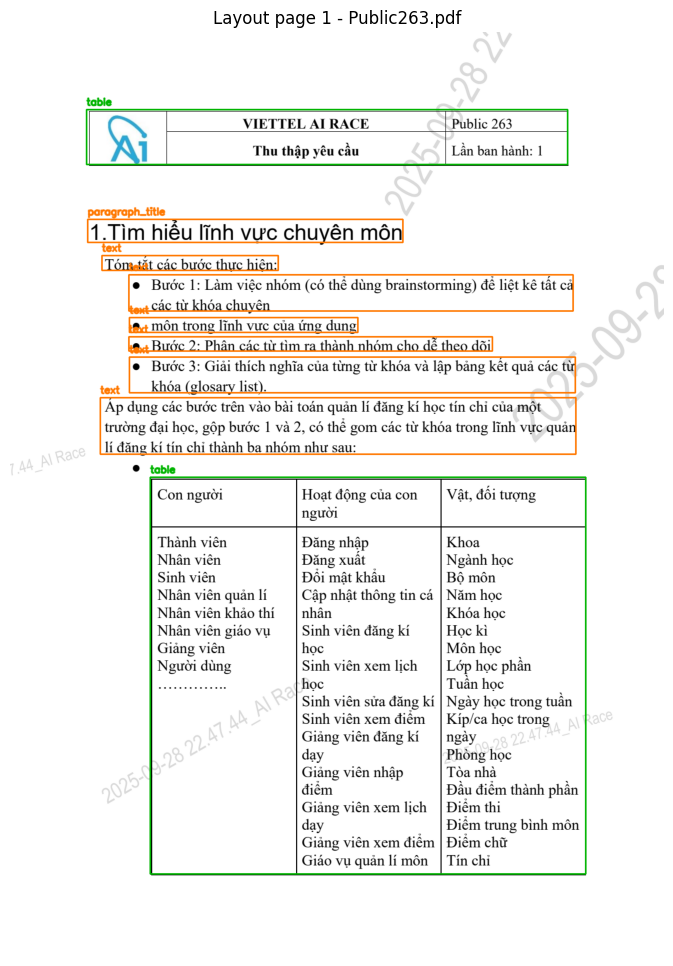

In [25]:
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import pypdfium2 as pdfium

from paddleocr import PPStructureV3

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data" / "Public263.pdf"  # doi file neu can

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file: {PDF_PATH}")

# 1) Render duy nhat trang dau tien cua PDF
pdf = pdfium.PdfDocument(str(PDF_PATH))
page0 = pdf[0]
bitmap = page0.render(scale=2.0)
pil_img = bitmap.to_pil()
page_img_bgr = cv2.cvtColor(cv2.cvtColor(__import__('numpy').array(pil_img), cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2RGB)
# page_img_bgr o dong tren thuc te dang RGB sau khi doi 2 lan, nen doi lai BGR de ve bang cv2
page_img_bgr = cv2.cvtColor(page_img_bgr, cv2.COLOR_RGB2BGR)

# 2) Chi chay layout parsing cho trang nay
layout_pipe = PPStructureV3(
    lang="vi",
    device="cpu",
    enable_mkldnn=False,
    enable_cinn=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    use_table_recognition=False,
    use_formula_recognition=False,
    use_seal_recognition=False,
    use_chart_recognition=False,
    use_region_detection=False,
)

res = layout_pipe.predict(page_img_bgr)
page_res = res[0]
blocks = page_res.get("parsing_res_list", [])

# 3) Ve bounding box len anh
canvas = page_img_bgr.copy()
label_counter = Counter()
for b in blocks:
    label = getattr(b, "label", "unknown")
    x1, y1, x2, y2 = map(int, getattr(b, "bbox", [0, 0, 0, 0]))
    label_counter[label] += 1

    color = (0, 180, 0) if label == "table" else (0, 120, 255)
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    cv2.putText(
        canvas,
        label,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
        cv2.LINE_AA,
    )

print(f"So block trang 1: {len(blocks)}")
print("Thong ke label:")
for label, count in label_counter.most_common():
    print(f"- {label}: {count}")

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"Layout page 1 - {PDF_PATH.name}")
plt.axis("off")
plt.show()

In [26]:
from pathlib import Path
import cv2
import pypdfium2 as pdfium
import torch
from PIL import Image
from paddleocr import PPStructureV3, PaddleOCRVL

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data" / "Public263.pdf" 
MAX_BLOCKS = None  

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file: {PDF_PATH}")

# ====== Load VietOCR local ======
import sys
sys.path.insert(0, str(BASE_DIR / "vietocr"))
from tool.config import Cfg
from tool.translate import build_model, process_input, translate

vietocr_cfg = Cfg.load_config_from_file(
    str(BASE_DIR / "vietocr" / "config" / "vgg-seq2seq.yml"),
    base_file=str(BASE_DIR / "vietocr" / "config" / "base.yml"),
)
vietocr_cfg["device"] = "cpu"

vietocr_model, vietocr_vocab = build_model(vietocr_cfg)
ckpt = torch.load(str(BASE_DIR / "vietocr" / "weight" / "vgg_seq2seq.pth"), map_location="cpu")
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    ckpt = ckpt["state_dict"]
if isinstance(ckpt, dict):
    ckpt = {(k[7:] if k.startswith("module.") else k): v for k, v in ckpt.items()}
vietocr_model.load_state_dict(ckpt, strict=False)
vietocr_model.eval()

# ====== Load pipeline ======
layout_pipe = PPStructureV3(
    lang="vi",
    device="cpu",
    enable_mkldnn=False,
    enable_cinn=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    use_table_recognition=False,
    use_formula_recognition=False,
    use_seal_recognition=False,
    use_chart_recognition=False,
    use_region_detection=False,
)

table_vl = PaddleOCRVL(
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_layout_detection=True,
    use_ocr_for_image_block=True,
    use_queues=False,
)

# ====== Render trang 1 ======
pdf = pdfium.PdfDocument(str(PDF_PATH))
page0 = pdf[0]
bitmap = page0.render(scale=2.0)
pil_img = bitmap.to_pil()
page_img_bgr = cv2.cvtColor(__import__('numpy').array(pil_img), cv2.COLOR_RGB2BGR)

# ====== Layout trang 1 ======
res = layout_pipe.predict(page_img_bgr)
blocks = res[0].get("parsing_res_list", [])
blocks = sorted(blocks, key=lambda b: (int(b.bbox[1]), int(b.bbox[0])))
if MAX_BLOCKS is not None:
    blocks = blocks[:MAX_BLOCKS]

print(f"So block duoc xu ly: {len(blocks)}")

# ====== OCR tung vung ======
for idx, b in enumerate(blocks, 1):
    label = getattr(b, "label", "unknown")
    x1, y1, x2, y2 = map(int, getattr(b, "bbox", [0, 0, 0, 0]))
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = max(x1 + 1, x2), max(y1 + 1, y2)

    crop = page_img_bgr[y1:y2, x1:x2]
    text_out = ""

    if label == "table":
        # Vung bang -> PaddleOCRVL
        import tempfile
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=True) as tmp:
            cv2.imwrite(tmp.name, crop)
            t_res = table_vl.predict(tmp.name)

        if t_res and t_res[0].get("parsing_res_list"):
            table_blocks = t_res[0]["parsing_res_list"]
            html_table = [str(tb.content) for tb in table_blocks if getattr(tb, "label", "") == "table"]
            text_out = "\n\n".join(html_table) if html_table else str(getattr(table_blocks[0], "content", ""))
        else:
            text_out = ""
    else:
        # Vung non-table -> VietOCR
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_pil = Image.fromarray(crop_rgb)
        tensor = process_input(
            crop_pil,
            vietocr_cfg["dataset"]["image_height"],
            vietocr_cfg["dataset"]["image_min_width"],
            vietocr_cfg["dataset"]["image_max_width"],
        ).to(vietocr_cfg["device"])

        pred_ids = translate(tensor, vietocr_model)
        if len(pred_ids) > 0:
            ids = pred_ids[0].tolist() if hasattr(pred_ids[0], "tolist") else list(pred_ids[0])
            text_out = vietocr_vocab.decode(ids)

    print(f"\n[{idx}] label={label} bbox={[x1, y1, x2, y2]}")
    print((text_out or "<empty>").strip()[:700])

/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-DocLayout_plus-L`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached file

So block duoc xu ly: 9


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/tensor/creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(



[1] label=table bbox=[139, 141, 1015, 241]
<table><tr><td rowspan="2">$ \boxed{A_1} $</td><td>VIETTEL AI RACE</td><td>Public 263</td></tr><tr><td>Thu thập yêu cầu</td><td>Lần ban hành: 1</td></tr></table>

[2] label=paragraph_title bbox=[141, 341, 715, 383]
1 Tìm hiểu lĩnh vực chuyên môn

[3] label=text bbox=[167, 407, 488, 434]
Tóm tắt các bước thực hiện:

[4] label=text bbox=[216, 442, 1025, 508]
Bược 1 Làm việc nhóm (có thể dùng brainstorming) để liệt kê tất cản

[5] label=text bbox=[217, 520, 633, 547]
0ôm nông lĩnh vực của ứng dụng

[6] label=text bbox=[216, 555, 878, 581]
Bước 2: Phân các từ tìm ra thành nhóm cho dõi

[7] label=text bbox=[217, 592, 1029, 657]
Biện được 3: Giải thích nghĩa của từng từ khóa và lập bảng kết quả các trinh

[8] label=text bbox=[164, 666, 1030, 769]
Ap để đó thi thi trong tiến trong tiến thiến thiến thiến thi trong thi trong thu trong thi thi thi thi thi thi tháng tháng tháng

[9] label=table bbox=[255, 811, 1048, 1534]
<table><tr><td>Con người</td><t

\- TEDS (Tree Edit Distance for Structure): Dành riêng cho bảng biểu. Nó không chỉ xem chữ trong ô đúng không mà còn xem cấu trúc hàng/cột có bị lệch không <br>
\- TED (Text Edit Distance) sau khi Normalize: Họ dùng các regex để biến tất cả bullet point về cùng một loại, xóa khoảng trắng thừa, rồi mới đo CER/WER <br>
\- BLEU/ROUGE-L: Đo độ tương đồng về ngữ nghĩa. Nếu sai một từ nối nhưng công thức toán đúng, điểm vẫn sẽ cao <br>
\- LaTeX Similarity: Riêng với công thức toán, parse sang cây cú pháp để so sánh

In [ ]:
from pathlib import Path
from collections import Counter
from io import StringIO
import math
import re

import pandas as pd

try:
    import jiwer
except Exception:
    jiwer = None

try:
    from nltk.translate.meteor_score import meteor_score
except Exception:
    meteor_score = None


class OCRBenchEvaluator:
    def __init__(self, lowercase=True, weights=None):
        self.lowercase = lowercase
        self.weights = weights or {"long_text": 0.5, "table": 0.25, "formula": 0.25}

    def evaluate_files(self, pred_path, gt_path):
        pred_text = Path(pred_path).read_text(encoding="utf-8", errors="ignore")
        gt_text = Path(gt_path).read_text(encoding="utf-8", errors="ignore")
        return self.evaluate_texts(pred_text, gt_text)

    def evaluate_texts(self, pred_text, gt_text):
        # normalize toàn document 
        pred = self._normalize_document(pred_text)
        gt = self._normalize_document(gt_text)

        # Lấy công thức rồi chấm formula_cer, sau đó loại bỏ công thức khỏi text để chấm các metric khác
        pred_formulas = self._extract_formulas(pred)
        gt_formulas = self._extract_formulas(gt)
        formula_cer = self._formula_cer(pred_formulas, gt_formulas)

        # Lấy bảng rồi chấm TEDS_Table
        pred_tables = self._extract_tables(pred)
        gt_tables = self._extract_tables(gt)
        pred_cells = self._flatten_cells(pred_tables)
        gt_cells = self._flatten_cells(gt_tables)
        table_score = self._table_score(pred_cells, gt_cells)

        # Loại bỏ công thức và bảng để chấm các metric text-only
        pred_text_only = self._extract_text_only(pred)
        gt_text_only = self._extract_text_only(gt)

        # Tính các metric text-only
        cer = self._cer(pred_text_only, gt_text_only)
        wer = self._wer(pred_text_only, gt_text_only)
        bleu = self._bleu(pred_text_only, gt_text_only)
        meteor = self._meteor(pred_text_only, gt_text_only)
        f1 = self._token_f1(pred_text_only, gt_text_only)
        ned = self._ned(pred_text_only, gt_text_only)
        long_text_hybrid = (bleu + meteor + f1 + ned) / 4.0

        final_score = self._final_score(long_text_hybrid, table_score, formula_cer)

        result = {
            "cer": cer, 
            "wer": wer,
            "teds_table": table_score,
            "formula_cer": formula_cer,
            "bleu": bleu, 
            "meteor": meteor,
            "f1": f1,
            "ned": ned,
            "long_text_hybrid": long_text_hybrid,
            "final_score": final_score,
            "pred_table_count": len(pred_tables),
            "gt_table_count": len(gt_tables),
            "pred_table_cells": len(pred_cells),
            "gt_table_cells": len(gt_cells),
        }

        summary_df = pd.DataFrame(
            [
                {
                    "CER": cer, # Mức sai khác ký tự 
                    "WER": wer, # Mức sai khác từ
                    "TEDS_Table": table_score if table_score is not None else pd.NA,
                    "Formula-CER": formula_cer,
                    "BLEU": bleu, # Mức khớp cụm từ + thứ tự 
                    "METEOR": meteor, # Mức khớp nội dung 
                    "F1": f1, # Mức khớp token (chỉ cần token nào đó của GT xuất hiện trong pred là được tính đúng)
                    "NED": ned, # Mức sai khác nội dung (đo bằng edit distance trên token)
                    "LongTextHybrid": long_text_hybrid, # Điểm tổng hợp cho text dài 
                    "Final_Score": final_score,
                    "Pred-Tables": len(pred_tables),
                    "GT-Tables": len(gt_tables),
                    "Pred-Cells": len(pred_cells),
                    "GT-Cells": len(gt_cells),
                }
            ]
        )
        return result, summary_df

    # Normalize
    def _normalize_document(self, s):
        s = s.replace("\r", "\n") # Chuẩn hóa xuống dòng
        if self.lowercase:
            s = s.lower()
        s = re.sub(r"<\s*br\s*/?\s*>", " ", s, flags=re.IGNORECASE) # Thay thẻ <br> bằng khoảng trắng
        s = re.sub(r"(?m)^\s*[*+]\s+", "- ", s) # Chuẩn hóa bullet marker * hoặc + thành -
        s = re.sub(r"(?m)^\s*-\s+", "- ", s) # Chuẩn hóa bullet marker - (nếu có khoảng trắng thừa) thành đúng format -
        return s

    # Formula 
    def _extract_formulas(self, s): 
        block = re.findall(r"\$\$(.+?)\$\$", s, flags=re.DOTALL) 
        s_no_block = re.sub(r"\$\$(.+?)\$\$", " ", s, flags=re.DOTALL) 
        inline = re.findall(r"\$(.+?)\$", s_no_block, flags=re.DOTALL) 
        return [re.sub(r"\s+", "", x).strip().lower() for x in (block + inline) if x.strip()] # 

    # Table 
    def _norm_cell(self, x):
        x = re.sub(r"<[^>]+>", " ", x)
        x = re.sub(r"\s+", " ", x)
        return x.strip()

    def _extract_markdown_tables(self, s):
        lines = s.splitlines()
        tables, i = [], 0

        def is_sep(line):
            return bool(re.fullmatch(r"\s*\|?\s*[:\-]+(?:\s*\|\s*[:\-]+)+\s*\|?\s*", line))

        while i < len(lines):
            if "|" not in lines[i]:
                i += 1
                continue
            j, chunk = i, []
            while j < len(lines) and "|" in lines[j]:
                chunk.append(lines[j])
                j += 1
            if any(is_sep(c) for c in chunk):
                rows = []
                for r in chunk:
                    if is_sep(r):
                        continue
                    cells = [self._norm_cell(p) for p in r.strip().strip("|").split("|")]
                    if len(cells) >= 2:
                        rows.append(cells)
                if rows:
                    tables.append(rows)
            i = j
        return tables

    def _extract_html_tables(self, s):
        out = []
        blocks = re.findall(r"<table[\s\S]*?</table>", s, flags=re.IGNORECASE)
        for t in blocks:
            try:
                for df in pd.read_html(StringIO(t)):
                    arr = [[self._norm_cell(str(x)) for x in row] for row in df.fillna("").astype(str).values.tolist()]
                    if arr:
                        out.append(arr)
            except Exception:
                pass

        # fallback for broken html fragments
        rows = []
        for rb in re.findall(r"<tr[^>]*>(.*?)</tr>", s, flags=re.IGNORECASE | re.DOTALL):
            cells = re.findall(r"<t[dh][^>]*>(.*?)</t[dh]>", rb, flags=re.IGNORECASE | re.DOTALL)
            cells = [self._norm_cell(c) for c in cells if self._norm_cell(c)]
            if len(cells) >= 2:
                rows.append(cells)
        if rows:
            out.append(rows)
        return out

    def _extract_tables(self, s):
        return self._extract_markdown_tables(s) + self._extract_html_tables(s)

    def _flatten_cells(self, tables):
        return [c for t in tables for row in t for c in row if c]

    def _table_score(self, pred_cells, gt_cells):
        if len(gt_cells) == 0:
            return None
        if len(pred_cells) == 0:
            return 0.0
        pc, gc = Counter(pred_cells), Counter(gt_cells)
        overlap = sum((pc & gc).values())
        p = overlap / sum(pc.values()) if pc else 0.0
        r = overlap / sum(gc.values()) if gc else 0.0
        return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

    # Text
    def _extract_text_only(self, s):
        s = re.sub(r"\$\$(.+?)\$\$", " ", s, flags=re.DOTALL)
        s = re.sub(r"\$(.+?)\$", " ", s, flags=re.DOTALL)
        s = re.sub(r"<table[\s\S]*?</table>", " ", s, flags=re.IGNORECASE)
        s = re.sub(r"<tr[\s\S]*?</tr>", " ", s, flags=re.IGNORECASE)
        s = re.sub(r"(?m)^\s*\|.*\|\s*$", " ", s)
        s = re.sub(r"(?m)^\s*\|?\s*[:\-]+(?:\s*\|\s*[:\-]+)+\s*\|?\s*$", " ", s)
        s = re.sub(r"(?m)^\s*#{1,6}\s*", "", s)
        s = re.sub(r"<[^>]+>", " ", s)
        return re.sub(r"\s+", " ", s).strip()

    # Metrics
    def _edit_distance(self, a, b):
        n, m = len(a), len(b)
        if n == 0:
            return m
        if m == 0:
            return n
        dp = list(range(m + 1))
        for i in range(1, n + 1):
            prev = dp[0]
            dp[0] = i
            for j in range(1, m + 1):
                temp = dp[j]
                cost = 0 if a[i - 1] == b[j - 1] else 1
                dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + cost)
                prev = temp
        return dp[m]

    def _cer(self, pred, gt):
        if jiwer is not None:
            try:
                return float(jiwer.cer(gt, pred))
            except Exception:
                pass
        return 0.0 if len(gt) == 0 and len(pred) == 0 else (1.0 if len(gt) == 0 else self._edit_distance(pred, gt) / len(gt))

    def _wer(self, pred, gt):
        if jiwer is not None:
            try:
                return float(jiwer.wer(gt, pred))
            except Exception:
                pass
        pw, gw = pred.split(), gt.split()
        return 0.0 if len(gw) == 0 and len(pw) == 0 else (1.0 if len(gw) == 0 else self._edit_distance(pw, gw) / len(gw))

    def _formula_cer(self, pred_f, gt_f):
        n = min(len(pred_f), len(gt_f))
        if n == 0:
            return 0.0 if len(pred_f) == len(gt_f) else 1.0
        vals = [self._cer(pred_f[i], gt_f[i]) for i in range(n)]
        unmatched = abs(len(pred_f) - len(gt_f))
        return (sum(vals) + unmatched) / (n + unmatched)

    def _bleu(self, pred, gt, max_n=4, smooth=1.0):
        hyp, ref = pred.split(), gt.split()
        if len(hyp) == 0:
            return 0.0
        if len(ref) == 0:
            return 1.0 if len(hyp) == 0 else 0.0

        ps = []
        for n in range(1, max_n + 1):
            h = Counter(tuple(hyp[i:i + n]) for i in range(max(0, len(hyp) - n + 1)))
            r = Counter(tuple(ref[i:i + n]) for i in range(max(0, len(ref) - n + 1)))
            overlap = sum((h & r).values())
            total = sum(h.values())
            ps.append((overlap + smooth) / (total + smooth) if total > 0 else 0.0)

        geo = math.exp(sum(math.log(p) for p in ps) / max_n)
        bp = 1.0 if len(hyp) > len(ref) else math.exp(1 - len(ref) / max(len(hyp), 1))
        return bp * geo

    def _meteor(self, pred, gt):
        hyp, ref = pred.split(), gt.split()
        if len(hyp) == 0 and len(ref) == 0:
            return 1.0
        if len(hyp) == 0 or len(ref) == 0:
            return 0.0
        if meteor_score is not None:
            try:
                return float(meteor_score([ref], hyp))
            except Exception:
                pass
        overlap = sum((Counter(hyp) & Counter(ref)).values())
        p, r = overlap / len(hyp), overlap / len(ref)
        return 0.0 if (p == 0 and r == 0) else (10 * p * r) / (r + 9 * p)

    def _token_f1(self, pred, gt):
        hyp, ref = pred.split(), gt.split()
        if len(hyp) == 0 and len(ref) == 0:
            return 1.0
        if len(hyp) == 0 or len(ref) == 0:
            return 0.0
        overlap = sum((Counter(hyp) & Counter(ref)).values())
        p, r = overlap / len(hyp), overlap / len(ref)
        return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

    def _ned(self, pred, gt):
        m = max(len(pred), len(gt))
        if m == 0:
            return 1.0
        return max(0.0, 1.0 - self._edit_distance(pred, gt) / m)

    def _final_score(self, long_text_hybrid, table_score, formula_cer):
        comp = {
            "long_text": long_text_hybrid,
            "table": table_score,
            "formula": max(0.0, 1.0 - formula_cer),
        }
        active = {k: v for k, v in comp.items() if v is not None}
        wsum = sum(self.weights[k] for k in active)
        if wsum == 0:
            return 0.0
        return sum((self.weights[k] / wsum) * float(v) for k, v in active.items())

PRED_FILE = Path("/media/data3/users/huytq/huy/outputs/Public039/Public039.md")
GT_FILE = Path("/media/data3/users/huytq/huy/ground_truth/Public039.md")

if not PRED_FILE.exists():
    raise FileNotFoundError(f"Khong tim thay prediction file: {PRED_FILE}")
if not GT_FILE.exists():
    raise FileNotFoundError(f"Khong tim thay ground-truth file: {GT_FILE}")

evaluator = OCRBenchEvaluator(lowercase=True)
result, summary_df = evaluator.evaluate_files(PRED_FILE, GT_FILE)

print("=== OCRBench Evaluation Summary ===")
print(f"CER            : {result['cer']:.4f}")
print(f"WER            : {result['wer']:.4f}")
print(f"BLEU           : {result['bleu']:.4f}")
print(f"METEOR         : {result['meteor']:.4f}")
print(f"F1             : {result['f1']:.4f}")
print(f"NED            : {result['ned']:.4f}")
print(f"LongTextHybrid : {result['long_text_hybrid']:.4f}")
if result['teds_table'] is None:
    print("TEDS_Table     : N/A (GT khong parse duoc bang)")
else:
    print(f"TEDS_Table     : {result['teds_table']:.4f}")
print(f"Formula-CER    : {result['formula_cer']:.4f}")
print(f"Final_Score    : {result['final_score']:.4f}")
print(f"Pred tables/cells: {result['pred_table_count']}/{result['pred_table_cells']}")
print(f"GT   tables/cells: {result['gt_table_count']}/{result['gt_table_cells']}")

print("\n=== DataFrame ===")
display(summary_df)

=== OCRBench Evaluation Summary ===
CER            : 0.1052
WER            : 0.0707
BLEU           : 0.8966
METEOR         : 0.9715
F1             : 0.9544
NED            : 0.9031
LongTextHybrid : 0.9314
TEDS_Table     : N/A (GT khong parse duoc bang)
Formula-CER    : 0.0000
Final_Score    : 0.9543
Pred tables/cells: 3/208
GT   tables/cells: 0/0

=== DataFrame ===


,CER,WER,TEDS_Table,Formula-CER,BLEU,METEOR,F1,NED,LongTextHybrid,Final_Score,Pred-Tables,GT-Tables,Pred-Cells,GT-Cells
0,0.105249,0.070707,<NA>,0.0,0.896568,0.971535,0.954407,0.903119,0.931407,0.954272,3,0,208,0


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
/media/data3/users/huytq/miniconda3/e

Tong so trang: 17
=== So bang moi trang ===
Trang 1: 1
Trang 2: 1
Trang 3: 1
Trang 4: 1
Trang 5: 1
Trang 6: 1
Trang 7: 1
Trang 8: 2
Trang 9: 1
Trang 10: 1
Trang 11: 1
Trang 12: 1
Trang 13: 1
Trang 14: 1
Trang 15: 1
Trang 16: 1
Trang 17: 1
Trang nhieu bang nhat: 8 (2 bang)
Da luu anh ket qua: /media/data3/users/huytq/huy/debug/Public283_table_transformer_page_008.png


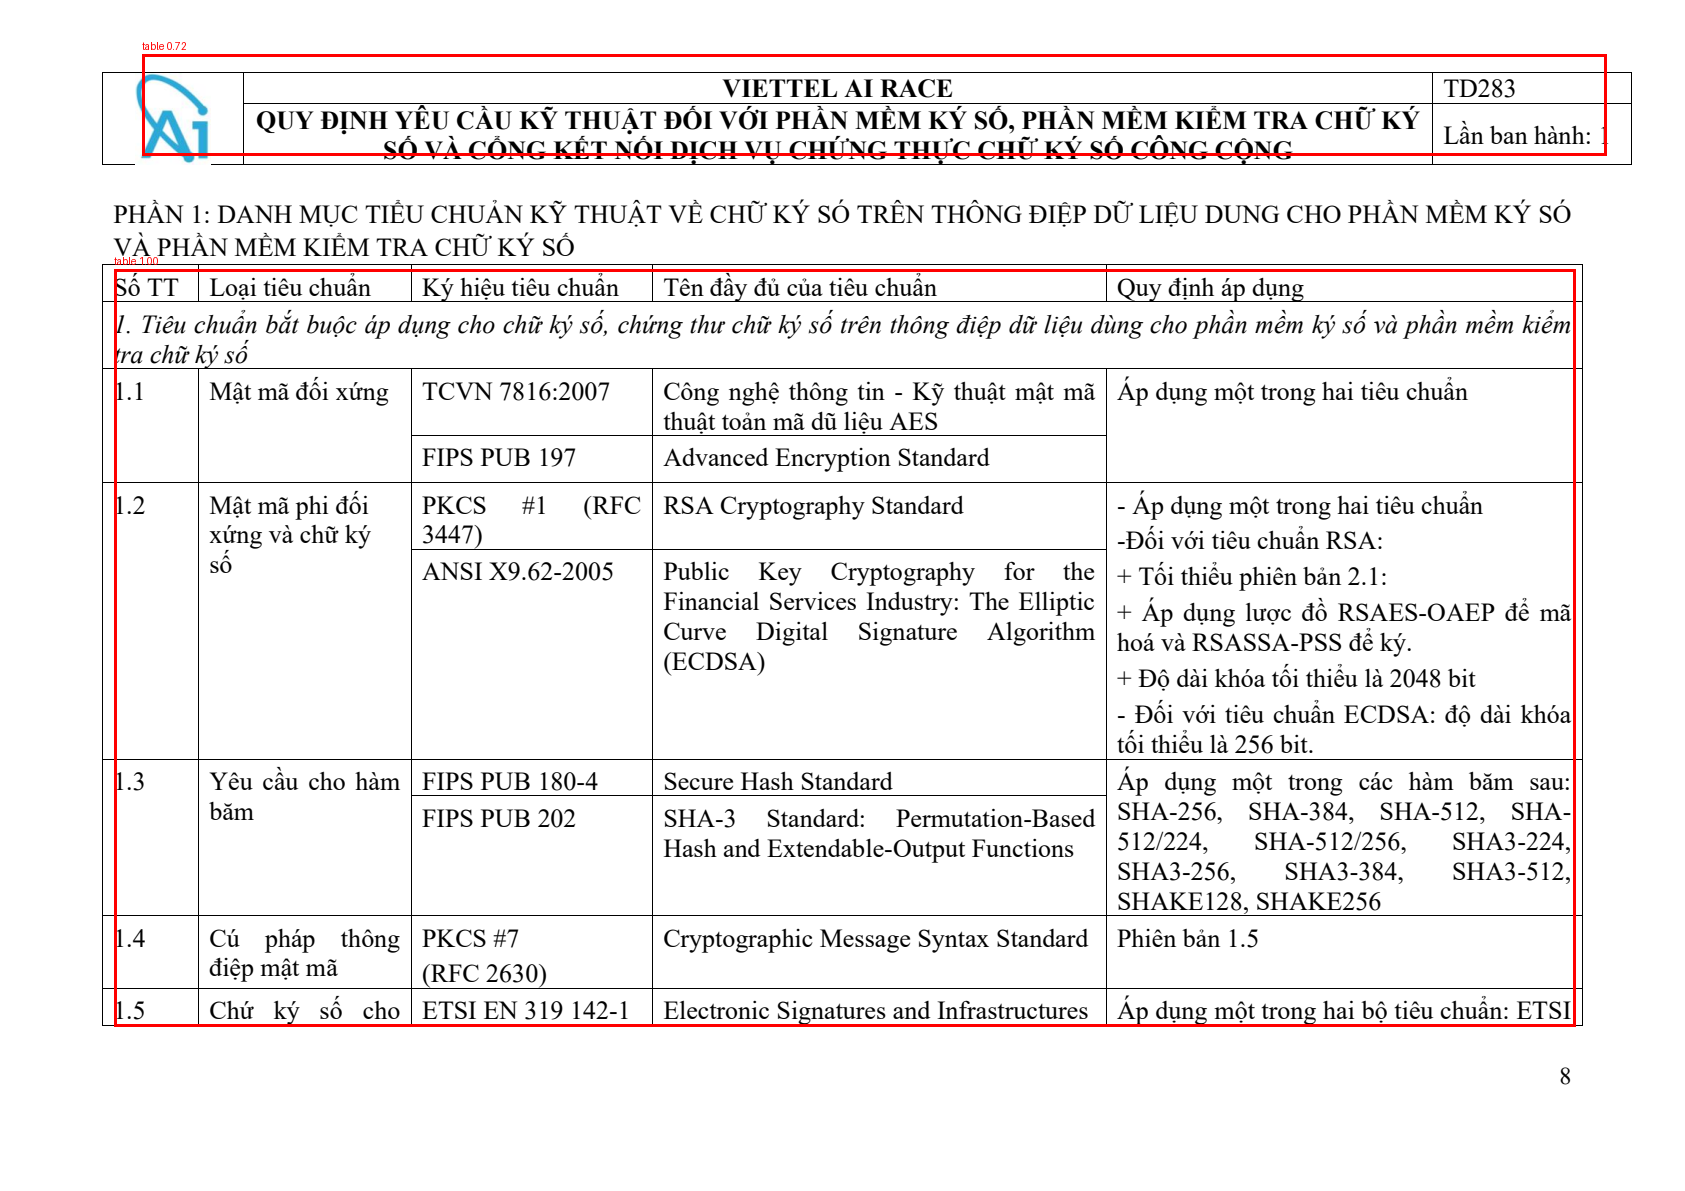

In [1]:
from pathlib import Path
import subprocess
import sys

import torch
from PIL import ImageDraw
import pypdfium2 as pdfium

# Ensure deps for Table Transformer
try:
    from transformers import AutoImageProcessor, TableTransformerForObjectDetection
except Exception:
    print("Dang cai transformers...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers", "-q"])
    from transformers import AutoImageProcessor, TableTransformerForObjectDetection

try:
    import timm  # noqa: F401
except Exception:
    print("Dang cai timm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "timm", "-q"])

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "surya" / "data" / "Public283.pdf"
OUT_DIR = BASE_DIR / "debug"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file PDF: {PDF_PATH}")

processor = AutoImageProcessor.from_pretrained("microsoft/table-transformer-detection")
model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-detection")
model.eval()

pdf = pdfium.PdfDocument(str(PDF_PATH))
num_pages = len(pdf)
print(f"Tong so trang: {num_pages}")

threshold = 0.7
page_counts = []
page_boxes = {}

for page_idx in range(num_pages):
    pil_img = pdf[page_idx].render(scale=2.0).to_pil().convert("RGB")
    inputs = processor(images=pil_img, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    target_sizes = torch.tensor([pil_img.size[::-1]])
    result = processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]

    boxes = []
    for box, score, label in zip(result["boxes"].tolist(), result["scores"].tolist(), result["labels"].tolist()):
        if label in (0, 1):
            boxes.append((box, score, label))

    page_no = page_idx + 1
    page_counts.append((page_no, len(boxes)))
    page_boxes[page_no] = boxes

print("=== So bang moi trang ===")
for page_no, cnt in page_counts:
    if cnt > 0:
        print(f"Trang {page_no}: {cnt}")

best_page, best_cnt = max(page_counts, key=lambda x: x[1])
print(f"Trang nhieu bang nhat: {best_page} ({best_cnt} bang)")

best_img = pdf[best_page - 1].render(scale=2.0).to_pil().convert("RGB")
draw = ImageDraw.Draw(best_img)
for box, score, _ in page_boxes[best_page]:
    x1, y1, x2, y2 = [int(v) for v in box]
    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
    draw.text((x1, max(0, y1 - 14)), f"table {score:.2f}", fill="red")

out_img = OUT_DIR / f"Public283_table_transformer_page_{best_page:03d}.png"
best_img.save(out_img)
print(f"Da luu anh ket qua: {out_img}")
best_img

In [2]:
from pathlib import Path
import cv2
import numpy as np
import tempfile

from paddleocr import PaddleOCRVL

# Yeu cau da chay cell Table Transformer truoc do de co: pdf, best_page, page_boxes
required_vars = ["pdf", "best_page", "page_boxes"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Thieu bien {missing}. Hay chay cell Table Transformer truoc.")

BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "debug"
OUT_DIR.mkdir(parents=True, exist_ok=True)

boxes = page_boxes.get(best_page, [])
if not boxes:
    raise RuntimeError(f"Khong co box bang nao o trang {best_page}")

# Chon box lon nhat de xuat HTML
largest_box = max(boxes, key=lambda x: (x[0][2] - x[0][0]) * (x[0][3] - x[0][1]))
box, score, label = largest_box
x1, y1, x2, y2 = [int(v) for v in box]

page_img = pdf[best_page - 1].render(scale=2.0).to_pil().convert("RGB")
page_np = np.array(page_img)

# Safe crop bounds
h, w = page_np.shape[:2]
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(w, x2), min(h, y2)
if x2 <= x1 or y2 <= y1:
    raise RuntimeError("Bounding box khong hop le de crop")

crop_rgb = page_np[y1:y2, x1:x2]
crop_bgr = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2BGR)

crop_img_path = OUT_DIR / f"Public283_best_table_page_{best_page:03d}.png"
cv2.imwrite(str(crop_img_path), crop_bgr)

# Table parsing bang PaddleOCRVL
table_vl = PaddleOCRVL(
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_layout_detection=True,
    use_ocr_for_image_block=True,
    use_queues=False,
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=True) as tmp:
    cv2.imwrite(tmp.name, crop_bgr)
    pred = table_vl.predict(tmp.name)

html_out = ""
if pred and pred[0].get("parsing_res_list"):
    parsed = pred[0]["parsing_res_list"]
    html_blocks = [str(b.content) for b in parsed if getattr(b, "label", "") == "table"]
    if html_blocks:
        html_out = "\n\n".join(html_blocks)
    elif len(parsed) > 0:
        html_out = str(getattr(parsed[0], "content", ""))

if not html_out.strip():
    html_out = "<!-- Khong trich xuat duoc HTML table -->"

html_path = OUT_DIR / f"Public283_best_table_page_{best_page:03d}.html"
html_path.write_text(html_out, encoding="utf-8")

print(f"Trang da chon: {best_page}")
print(f"BBox lon nhat: {[x1, y1, x2, y2]} | score={score:.3f} | label={label}")
print(f"Anh crop: {crop_img_path}")
print(f"HTML xuat ra: {html_path}")

print("\n=== HTML preview (1000 ky tu dau) ===")
print(html_out[:1000])

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-DocLayoutV3', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-DocLayoutV3`.
/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PaddleOCR-VL-1.5-0.9B', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PaddleOCR-VL-1.5`.
Loading configuration file /media/data3/users/huytq/.paddlex/official_mo

Trang da chon: 8
BBox lon nhat: [114, 269, 1575, 1026] | score=1.000 | label=0
Anh crop: /media/data3/users/huytq/huy/debug/Public283_best_table_page_008.png
HTML xuat ra: /media/data3/users/huytq/huy/debug/Public283_best_table_page_008.html

=== HTML preview (1000 ky tu dau) ===
<table><tr><td>Số TT</td><td>Loại tiêu chuẩn</td><td>Ký hiệu tiêu chuẩn</td><td>Tên đầy đủ của tiêu chuẩn</td><td>Quy định áp dụng</td></tr></table>

<table><tr><td rowspan="2">1. Tiêu chuẩn bắt buộc áp dụng cho chữ ký số, chứng thư chữ ký số trên thông 1</td><td rowspan="2">1.1</td><td rowspan="2">Mật mã đối xứng</td><td>TCVN 7816:2007</td><td>Công nghệ thông tin - Kỹ thuật mật mã thuật toản mã dũ liệu AES</td><td rowspan="2">Áp dụng một trong hai tiêu chuẩn</td></tr><tr><td>FIPS PUB 197</td><td>Advanced Encryption Standard</td></tr><tr><td rowspan="2">1.2</td><td rowspan="2">Mật mã phi đối xứng và chữ ký số</td><td rowspan="2">PKCS #1 (RFC 3447)</td><td>RSA Cryptography Standard</td><td colspan="2">- Áp dụng

In [2]:
from pathlib import Path

DATA_DIR = Path('/media/data3/users/huytq/huy/input')
if not DATA_DIR.exists():
    DATA_DIR = Path('/media/data3/users/huytq/input')

pdf_files = sorted(DATA_DIR.glob('*.pdf'))
assert pdf_files, f'Khong tim thay PDF trong {DATA_DIR}'

pdf_index = 0
pdf_path = pdf_files[pdf_index]

max_pages = 3
print(f'Tim thay {len(pdf_files)} file PDF')
for i, p in enumerate(pdf_files):
    print(f'[{i}] {p.name}')
print(f'\nDang test: {pdf_path.name}, max_pages={max_pages}')
print(f'DATA_DIR: {DATA_DIR}')

Tim thay 199 file PDF
[0] Public001.pdf
[1] Public002.pdf
[2] Public003.pdf
[3] Public004.pdf
[4] Public005.pdf
[5] Public006.pdf
[6] Public007.pdf
[7] Public008.pdf
[8] Public009.pdf
[9] Public010.pdf
[10] Public011.pdf
[11] Public012.pdf
[12] Public013.pdf
[13] Public014.pdf
[14] Public015.pdf
[15] Public016.pdf
[16] Public017.pdf
[17] Public018.pdf
[18] Public019.pdf
[19] Public020.pdf
[20] Public021.pdf
[21] Public022.pdf
[22] Public023.pdf
[23] Public024.pdf
[24] Public025.pdf
[25] Public026.pdf
[26] Public027.pdf
[27] Public028.pdf
[28] Public029.pdf
[29] Public030.pdf
[30] Public031.pdf
[31] Public032.pdf
[32] Public033.pdf
[33] Public034.pdf
[34] Public035.pdf
[35] Public036.pdf
[36] Public037.pdf
[37] Public038.pdf
[38] Public039.pdf
[39] Public040.pdf
[40] Public041.pdf
[41] Public042.pdf
[42] Public043.pdf
[43] Public044.pdf
[44] Public045.pdf
[45] Public046.pdf
[46] Public047.pdf
[47] Public048.pdf
[48] Public049.pdf
[49] Public050.pdf
[50] Public051.pdf
[51] Public052.pdf


In [3]:
import torch
import pypdfium2 as pdfium # thư viện để đọc và render PDF
from surya.foundation import FoundationPredictor
from surya.layout import LayoutPredictor
from surya.settings import settings as surya_settings

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print('Device:', device)

layout_model = LayoutPredictor(
    FoundationPredictor(
        checkpoint=surya_settings.LAYOUT_MODEL_CHECKPOINT,
        device=device,
    )
)

pdf_doc = pdfium.PdfDocument(str(pdf_path))
page_count = len(pdf_doc)
run_pages = min(max_pages, page_count)

images = []
for page_id in range(run_pages):
    page = pdf_doc[page_id]
    # scale=96/72 ~ 96 DPI, giong lowres image trong Marker
    pil_image = page.render(scale=96 / 72).to_pil()
    images.append(pil_image)

layout_results = layout_model(images, batch_size=min(6, len(images)))

print(f'Processed {len(layout_results)} / {page_count} pages')
for i, result in enumerate(layout_results):
    labels = [b.label for b in result.bboxes]
    uniq = sorted(set(labels))
    print(f'Page {i}: {len(labels)} blocks | labels={uniq}')

Device: cpu


Recognizing Layout: 100%|██████████| 3/3 [00:31<00:00, 10.44s/it]

Processed 3 / 12 pages
Page 0: 11 blocks | labels=['SectionHeader', 'Text']
Page 1: 14 blocks | labels=['Picture', 'SectionHeader', 'Text']
Page 2: 14 blocks | labels=['SectionHeader', 'Text']


Ve label "Picture" tai (129.890625, 50.53125)
Ve label "SectionHeader" tai (299.625, 53.109375)
Ve label "SectionHeader" tai (227.5078125, 74.765625)
Ve label "Text" tai (553.828125, 54.140625)
Ve label "Text" tai (560.6015625, 87.140625)
Ve label "SectionHeader" tai (94.828125, 136.640625)
Ve label "Text" tai (94.03125, 157.78125)
Ve label "Text" tai (94.03125, 388.265625)
Ve label "Text" tai (95.625, 563.0625)
Ve label "SectionHeader" tai (134.2734375, 668.765625)
Ve label "SectionHeader" tai (150.2109375, 692.484375)
Ve label "Text" tai (92.4375, 712.59375)
Ve label "Text" tai (32.671875, 581.625)
Ve label "Text" tai (672.9609375, 889.96875)


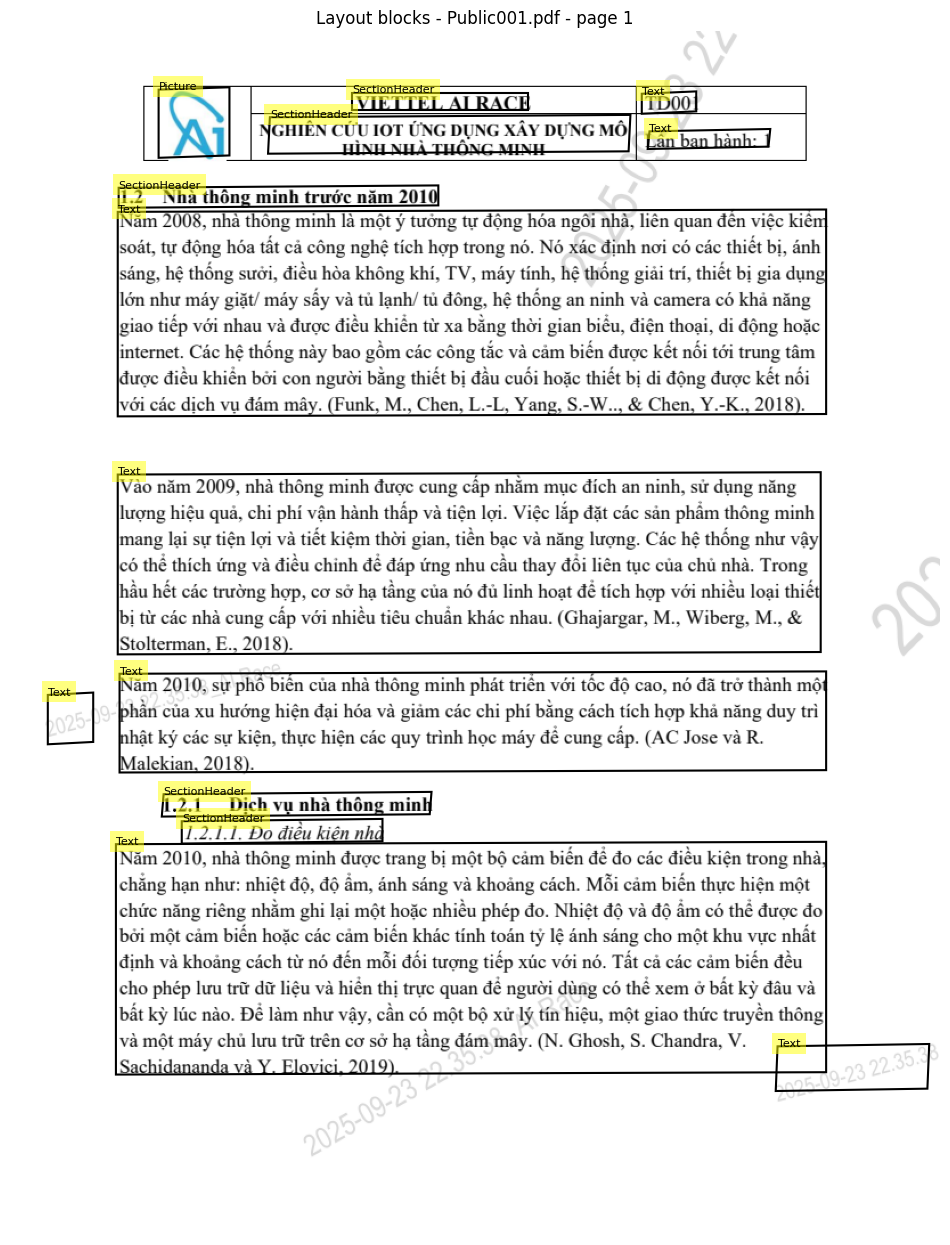

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

viz_page = 1
img = images[viz_page]
result = layout_results[viz_page]

fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(img)
ax.set_title(f'Layout blocks - {pdf_path.name} - page {viz_page}')
ax.axis('off')

for box in result.bboxes:
    poly = Polygon(box.polygon, closed=True, fill=False, linewidth=1.5)
    ax.add_patch(poly)
    x0, y0 = box.polygon[0]
    print(f'Ve label "{box.label}" tai ({x0}, {y0})')
    ax.text(x0, y0, box.label, fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='none'))

plt.show()

In [2]:
!pip install docling

  Using cached docling-2.80.0-py3-none-any.whl.metadata (12 kB)
  Using cached docling_core-2.70.1-py3-none-any.whl.metadata (8.1 kB)
  Using cached docling_parse-5.5.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.9 kB)
  Using cached docling_ibm_models-3.12.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached rapidocr-3.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached rtree-1.4.1-py3-none-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached typer-0.21.2-py3-none-any.whl.metadata (16 kB)
  Using cached python_docx-1.2.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached python_pptx-1.0.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached marko-2.2.2-py3-none-any.whl.metadata (4.5 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached pylatexenc-2.10-py3-none-any.whl
  Using cached polyfactory-3.3.0-py3-none-any.whl.metadata (27 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  

In [5]:
from pathlib import Path
from docling.document_converter import DocumentConverter

pdf_path = Path("/media/data3/users/huytq/huy/temp.pdf")
if not pdf_path.exists():
    pdf_path = Path("/media/data3/users/huytq/huy/input/Public001.pdf")

print(f"Testing Docling OCR on: {pdf_path}")
print(f"File exists: {pdf_path.exists()}")
print(f"File size: {pdf_path.stat().st_size / 1024 / 1024:.2f} MB")

converter = DocumentConverter()
print("\nConverting PDF with Docling...")
res = converter.convert(pdf_path)

doc_obj = getattr(res, "document", res)

# Try common export APIs across docling versions
markdown_output = ""
if hasattr(doc_obj, "export_to_markdown"):
    markdown_output = doc_obj.export_to_markdown()
elif hasattr(res, "export_to_markdown"):
    markdown_output = res.export_to_markdown()

if not markdown_output:
    markdown_output = str(doc_obj)

print("\n=== DOCUMENT SUMMARY ===")
print(f"Conversion result type: {type(res)}")
print(f"Document object type: {type(doc_obj)}")
print(f"Markdown length: {len(markdown_output)}")

# Best-effort page count
page_count = None
if hasattr(doc_obj, "pages"):
    try:
        page_count = len(doc_obj.pages)
    except Exception:
        pass
if page_count is None and hasattr(res, "pages"):
    try:
        page_count = len(res.pages)
    except Exception:
        pass

if page_count is not None:
    print(f"Number of pages: {page_count}")
else:
    print("Number of pages: N/A (API khong expose truc tiep)")

print("\n=== FIRST 1000 CHARS OF MARKDOWN ===")
print(markdown_output[:1000])
print("\n... [truncated]")

[INFO] 2026-03-20 10:54:04,958 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-20 10:54:04,968 [RapidOCR] download_file.py:60: File exists and is valid: /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-20 10:54:04,968 [RapidOCR] main.py:53: Using /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-20 10:54:05,042 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-20 10:54:05,044 [RapidOCR] download_file.py:60: File exists and is valid: /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-20 10:54:05,045 [RapidOCR] main.py:53: Using /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-20 10:54:05,079 [RapidOCR] base

Testing Docling OCR on: /media/data3/users/huytq/huy/temp.pdf
File exists: True
File size: 15.31 MB

Converting PDF with Docling...


[INFO] 2026-03-20 10:54:05,101 [RapidOCR] download_file.py:60: File exists and is valid: /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx
[INFO] 2026-03-20 10:54:05,101 [RapidOCR] main.py:53: Using /media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx



=== DOCUMENT SUMMARY ===
Conversion result type: <class 'docling.datamodel.document.ConversionResult'>
Document object type: <class 'docling_core.types.doc.document.DoclingDocument'>
Markdown length: 29330
Number of pages: 12

=== FIRST 1000 CHARS OF MARKDOWN ===
## HINHNHATHONGMINH

Lanban hanh:1

Cong nghe ting dung vao mo hinh nha thong minh dua tren Internet van vat (loT -Internet of Things) phan lon bj han che va phan tan. Cac danh gia trong bai viet duoe thyc hien de phan logi boi canh nghien ciru ve trng dung loT xay dumg mo hinh nha thong minh, nham cung cap nhirng hieu biet co gid tri ve cong nghe va ho trg cac nha nghien ciru hieu cac nen tang co san va cac lo hong trong linh vrc nay. Chuing toi tien hanh tim kiem cac bai viet lien quan den (l) nha thong minh, (2) ing dung va (3) IoT trong ba co so dir lieu chinh, cy the la: Web of Science, ScienceDirect va IEEE Explore. Cac co so dir lieu nay chira tai lieu ve cac ing dung nha thong minh stir dung loT. Tap dir lieu thu duoc

In [11]:
from pathlib import Path
import fitz
import pdfplumber

INPUT_PDF = Path("/media/data3/users/huytq/huy/input/Public283.pdf")
OUTPUT_PDF = INPUT_PDF.with_name(f"{INPUT_PDF.stem}_cropped.pdf")
BUFFER_RATIO = 0.005  

if not INPUT_PDF.exists():
    raise FileNotFoundError(f"Khong tim thay file: {INPUT_PDF}")


def find_crop_ratio_with_pdfplumber(pdf_path: Path, buffer_ratio: float = 0.005):
    with pdfplumber.open(str(pdf_path)) as pdf:
        if not pdf.pages:
            return None
        first_page = pdf.pages[0]
        tables = first_page.find_tables()
        if not tables:
            return None

        # bbox = (x0, top, x1, bottom)
        first_table_bbox = tables[0].bbox
        page_height = first_page.height
        table_bottom = first_table_bbox[3]
        crop_ratio = (table_bottom / page_height) + buffer_ratio
        return min(max(crop_ratio, 0.0), 0.95)


def crop_pdf_top(input_pdf: Path, output_pdf: Path, crop_ratio: float):
    doc = fitz.open(str(input_pdf))
    for page in doc:
        rect = page.rect
        crop_rect = fitz.Rect(
            rect.x0,
            rect.y0 + rect.height * crop_ratio,
            rect.x1,
            rect.y1,
        )
        page.set_cropbox(crop_rect)
    doc.save(str(output_pdf))
    doc.close()


crop_ratio = find_crop_ratio_with_pdfplumber(INPUT_PDF, BUFFER_RATIO)
if crop_ratio is None:
    crop_ratio = 0.10
    print("Khong tim thay table o trang 1 -> fallback crop_ratio=0.10")

crop_pdf_top(INPUT_PDF, OUTPUT_PDF, crop_ratio)

print("=== CROP HEADER DONE ===")
print(f"Input : {INPUT_PDF}")
print(f"Output: {OUTPUT_PDF}")
print(f"Crop ratio: {crop_ratio:.4f}")

=== CROP HEADER DONE ===
Input : /media/data3/users/huytq/huy/input/Public283.pdf
Output: /media/data3/users/huytq/huy/input/Public283_cropped.pdf
Crop ratio: 0.1435


In [15]:
from pathlib import Path
import re

MD_FILE = Path("/media/data3/users/huytq/huy/viettel_pipeline_test_public283/output/Public283_cropped/Public283_cropped.md")

text = MD_FILE.read_text(encoding="utf-8", errors="ignore")
lines = text.split("\n")

# Tach lines thanh blocks
blocks = []
i = 0
while i < len(lines):
    line = lines[i]
    is_table_line = line.strip().startswith("|") and line.strip().endswith("|")
    
    if is_table_line:
        table_lines = [line]
        j = i + 1
        while j < len(lines):
            if lines[j].strip().startswith("|") and lines[j].strip().endswith("|"):
                table_lines.append(lines[j])
                j += 1
            else:
                break
        blocks.append(("table", table_lines))
        i = j
    else:
        text_lines = [line]
        j = i + 1
        while j < len(lines):
            next_line = lines[j]
            if next_line.strip().startswith("|") and next_line.strip().endswith("|"):
                break
            text_lines.append(next_line)
            j += 1
        blocks.append(("text", text_lines))
        i = j

print(f"Tach thanh {len(blocks)} blocks")

# Kiem tra xem nhung cap table nao can ghep
# Ghep khi: text giua 2 tables chi la whitespace (khong co content)
ghep_pairs = []
for i in range(len(blocks) - 1):
    if blocks[i][0] == "table" and blocks[i + 1][0] == "text":
        text_between = "\n".join(blocks[i + 1][1])
        # Chi ghep neu text giua khong co noi dung (chi whitespace/empty)
        if not text_between.strip():
            if i + 2 < len(blocks) and blocks[i + 2][0] == "table":
                ghep_pairs.append((i, i + 2))

print(f"Tong cap can ghep: {len(ghep_pairs)}")
if ghep_pairs:
    for idx1, idx2 in ghep_pairs:
        print(f"  Ghep table {idx1} va table {idx2}")

# Xac dinh separator line (chi chua | va dau -)
def is_separator_line(line):
    return bool(re.match(r"^\s*\|[\s\-|:]+\|\s*$", line.strip()))

# Thuc hien ghep
final_blocks = list(blocks)
for table1_idx, table2_idx in reversed(ghep_pairs):
    table1_lines = final_blocks[table1_idx][1]
    table2_lines = final_blocks[table2_idx][1]
    
    # Xoa dong separator cuoi cua table1 neu co
    while table1_lines and is_separator_line(table1_lines[-1]):
        table1_lines.pop()
    
    # Tim separator line trong table2
    separator_idx = -1
    for idx, line in enumerate(table2_lines):
        if is_separator_line(line):
            separator_idx = idx
            break
    
    if separator_idx >= 0:
        data_rows = table2_lines[separator_idx + 1:]
        merged_lines = table1_lines + data_rows
    else:
        merged_lines = table1_lines + table2_lines
    
    final_blocks[table1_idx] = ("table", merged_lines)
    final_blocks[table1_idx + 1] = ("delete", None)
    final_blocks[table2_idx] = ("delete", None)

# Loai bo cac blocks "delete"
final_blocks = [b for b in final_blocks if b[0] != "delete"]

# Reconstruct output
output_lines = []
for block_type, block_data in final_blocks:
    if block_type == "text":
        output_lines.extend(block_data)
    elif block_type == "table":
        output_lines.extend(block_data)

output_text = "\n".join(output_lines)
output_path = MD_FILE.with_name(f"{MD_FILE.stem}_table_merged.md")
output_path.write_text(output_text + "\n", encoding="utf-8")

print(f"\n=== KET QUA ===")
print(f"Output: {output_path}")
print(f"Do dai goc: {len(text)} ky tu")
print(f"Do dai sau ghep: {len(output_text)} ky tu")
print(f"Tiet kiem: {len(text) - len(output_text)} ky tu")

Tach thanh 21 blocks
Tong cap can ghep: 8
  Ghep table 1 va table 3
  Ghep table 3 va table 5
  Ghep table 5 va table 7
  Ghep table 7 va table 9
  Ghep table 9 va table 11
  Ghep table 11 va table 13
  Ghep table 15 va table 17
  Ghep table 17 va table 19

=== KET QUA ===
Output: /media/data3/users/huytq/huy/viettel_pipeline_test_public283/output/Public283_cropped/Public283_cropped_table_merged.md
Do dai goc: 46921 ky tu
Do dai sau ghep: 41949 ky tu
Tiet kiem: 4972 ky tu


In [16]:
from pathlib import Path

MD_FILE = Path("/media/data3/users/huytq/huy/viettel_pipeline_test_public283/output/Public283_cropped/Public283_cropped.md")

text = MD_FILE.read_text(encoding="utf-8", errors="ignore")
lines = text.split("\n")

# Tim dau tien cua "Bảng", "table", "<table", "|" de xem co bang khong
print("=== KIEM TRA DINH DANG BANG ===")
print(f"Tong so dong: {len(lines)}\n")

# Tim nhung dong chua "table" (case-insensitive)
table_lines = [i for i, l in enumerate(lines) if "table" in l.lower()]
print(f"Tim thay {len(table_lines)} dong chua 'table'")
if table_lines:
    for idx in table_lines[:5]:
        print(f"  Dong {idx}: {lines[idx][:100]}")

# Tim nhung dong chua "|" (markdown table)
pipe_lines = [i for i, l in enumerate(lines) if "|" in l and l.strip()]
print(f"\nTim thay {len(pipe_lines)} dong chua '|' (markdown table)")
if pipe_lines:
    for idx in pipe_lines[:5]:
        print(f"  Dong {idx}: {lines[idx][:100]}")

# Tim nhung dong chua "<table"
html_table_lines = [i for i, l in enumerate(lines) if "<table" in l.lower()]
print(f"\nTim thay {len(html_table_lines)} dong chua '<table'")
if html_table_lines:
    for idx in html_table_lines[:5]:
        print(f"  Dong {idx}: {lines[idx][:100]}")

# Tim nhung dong chua "|<image" (placeholder images)
image_lines = [i for i, l in enumerate(lines) if "|<image" in l]
print(f"\nTim thay {len(image_lines)} dong chua image placeholder")
if image_lines:
    for idx in image_lines[:5]:
        print(f"  Dong {idx}: {lines[idx][:100]}")

print(f"\n=== PREVIEW xung quanh cac dau hieu ===")

# Lay 5-10 dong dau tien sau heading
heading_lines = [i for i, l in enumerate(lines) if l.strip().startswith("#")]
if heading_lines:
    start_preview = heading_lines[0]
    end_preview = min(start_preview + 15, len(lines))
    print(f"Dau tien sau heading (dong {start_preview}-{end_preview}):")
    for idx in range(start_preview, end_preview):
        print(f"  {idx}: {lines[idx][:80]}")

=== KIEM TRA DINH DANG BANG ===
Tong so dong: 253

Tim thay 4 dong chua 'table'
  Dong 152: |     |                            | ISO 32000-<br>1:2008 | Document<br>management<br>-<br>Portable<
  Dong 154: |     |                            | ISO 32000-<br>2:2020 | Document<br>management<br>-<br>Portable<
  Dong 199: | 3.6 | Định<br>dạng PDF                                                  | ISO 32000-<br>1:2008    
  Dong 200: |     |                                                                   | ISO 32000-<br>2:2020    

Tim thay 84 dong chua '|' (markdown table)
  Dong 137: | Số<br>TT | Loại tiêu chuẩn                                                                        
  Dong 138: |----------|----------------------------------------------------------------------------------------
  Dong 139: | tra chữ  | 1. Tiêu chuẩn bắt buộc áp dụng cho chữ<br>ký số, chứng thư chữ<br>ký số<br>trên thông đ
  Dong 140: | 1.1      | Mật mã đối xứng                                             